# Assignment 4. Color and Multi-Scale Representations

<span style="color:orange">Ground Rules for the Assignment: </span>

* <span style="color:lightblue"> You can only use basic functions (matrix operations, input/output image functions, plotters). Anything else, you need to code from scratch (histogram functions, inverting gamma functions, color matting, histogram equalization)</span>
* <span style="color:lightblue"> The code needs to be appropiately commented and should be reproducible; if we cannot re-generate your figures from your code, we will deduct points.</span>
* <span style="color:lightblue">The notebook report should be detailed and include partial and final solutions for each exercise. We grade solely the report; code without report will not be graded, so we encourage that you invest some time on it</span>
* <span style="color:lightblue">Interactive plots are welcome but most important results should be static and generated beforehand</span>
* <span style="color:lightblue">__Remember to remove all plots from the "coding" sections.__ Only the Report should output plots and/or images.</span>


<span style="color:orange">Submission Details</span>

Simply submit this Jupyter Notebook with the report inlined as described below. The notebook should be executed before submission. Name the file as 
```surname1_name1_surname2_name2_assignment3.ipynb```


In [4]:
# Loading Libraries you will need for the assignment.- Install them in your environment if you haven't done so yet
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2 #opencv python
from matplotlib.axes import Axes

# 0. Helpers

In [5]:
def load_rgb_image(path: str, max_size: tuple[int, int] | None = None) -> Image.Image:
    """Load an image in RGB mode.

    A maximum size can optionally be provided to keep the notebook lightweight and
    reproducible when the original files are very large.
    """
    image = Image.open(path).convert("RGB")
    if max_size is not None:
        image.thumbnail(max_size, Image.Resampling.LANCZOS)
    return image


def image2array(image: Image.Image) -> np.ndarray:
    """Convert a PIL image to a float32 NumPy array in [0, 1]."""
    image = np.array(image)
    image = image.astype(np.float32) / 255.0
    return image


def array2image(image: np.ndarray) -> Image.Image:
    """Convert a float image in [0, 1] back to an 8-bit PIL image."""
    image = np.clip(image * 255, 0, 255).astype(np.uint8)
    return Image.fromarray(image)


def display(
        image: Image.Image | np.ndarray, gamma: float | None = None, title: str | None = None, ax: Axes | None = None
):
    """Display an image.

    gamma=None (or 0) means the image is already in display space.
    A positive gamma value is applied before display, which is useful for visualizing
    linear images.
    """
    if isinstance(image, Image.Image):
        image = image2array(image)

    if gamma not in (None, 0):
        image = np.clip(image, 0, 1) ** gamma

    cmap = None
    if image.ndim == 2:
        cmap = 'grey'

    if ax is not None:
        ax.imshow(np.clip(image, 0, 1), cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
        return

    plt.imshow(np.clip(image, 0, 1), cmap=cmap)
    plt.title(title)
    plt.axis("off")

## 1 Color Palette Extraction from Images [8 Points]
Color palettes are a fundamental tool for both physical and digital artists. These sets of colors are a meaningful representation of all colors present in an image or piece of art, enabling the artist to tweak them for specific artistic effects. Purely decomposing an image into all of its colors can create "accurate" color palettes, but in natural images and paintings these would feature thousands of different colors and thus the palette becomes unmanageable. On the other extreme, a color palette solely composed of cyan, magenta and yellow (or red, green and blue in digital art) is a possible solution always, as these can create a wide range of visible colors, but they are not very helpful in describing the specific colors that best define a picture and thus using them to intuitively edit them or change their style is impossible. Best color palettes for digital image editing not only describe the colors that best define the style of a picture, but rather do so in a localized or semantic way. For example, the color of human skin and of a building painted pink could be rendered with similar colors, but editing them together to change the style of our picture would probably be undesired.

### 1.1 Linear RGB and sRGB Color Palettes
In this exercise, we ask you to implement a simple way of extracting a meaningful and interesting color palette from a single image. The end result will be the decomposition of the original image into a set of color layers that together add up to the initial image. We will first ask you to compute two different palettes, one starting from the image `queen.jpg` in linear RGB space, and the other in sRGB space. The process can be broadly described in 3 steps:
1. Loading Image in RGB space: Load the image and implement your own function to transform it to linear RGB (invert sRGB transform, see Lecture #8).
2. Color Clustering: We will now cluster those colors according to color similarity in RGB and sRGB spaces (this means that similar values will be clustered together, and its average will be a distinct palette color). To do this, you will use K-means clustering, so that they are divided in 7 clusters, selecting the centroid of each as representing color. You can use MATLAB’s function kmeans, but to do so you will first need to install MATLAB’s Statistics and Machine Learning Toolbox.
3. Image Decomposition into Base Color Layers: Now that you have your color palette, we will create 7 layers where we select only the pixels of the image whose colors we included in each individual cluster (see Figure 1). All other pixels will be set to black. The resulting layers will together add up to the initial image. Finally, translate each layer into HSL color space. This will enable intuitive editing of similar colors together, and applying changes to the image will limit to a simple addition of all layers. Additionally, draw a color strip with the centroids (average colors) of each filter/layer, which will be the representing colors of your palette (Figure 1).

Include a figure in your report with your resulting color layers from this step. Compare both linear and standard RGB palettes, arguing about quality.

In [15]:
def srgb_to_linear(image: Image.Image | np.ndarray) -> np.ndarray:
    """Convert an sRGB image in [0, 1] to linear RGB.

    This is the exact inverse sRGB transfer function. It is better than a simple
    gamma=2.2 approximation, although the gamma approximation gives a similar idea.
    """
    if isinstance(image, Image.Image):
        image = image2array(image)

    image = np.clip(image, 0, 1)

    linear = np.where(
        image <= 0.04045,
        image / 12.92,
        ((image + 0.055) / 1.055) ** 2.4
    )
    return linear


def linear_to_srgb(image: np.ndarray) -> np.ndarray:
    """Convert a linear RGB image in [0, 1] back to sRGB display space."""
    image = np.clip(image, 0, 1)

    srgb = np.where(
        image <= 0.0031308,
        12.92 * image,
        1.055 * (image ** (1 / 2.4)) - 0.055
    )
    return np.clip(srgb, 0, 1)


def gamma_correction(image: Image.Image | np.ndarray, gamma: float = 2.2) -> np.ndarray:
    """Apply a power-law transform.

    For JPEG linearization, gamma=2.2 approximately inverts the standard display encoding.
    For visualization of linear data, gamma=1/2.2 maps it back to display space.
    """
    if isinstance(image, Image.Image):
        image = image2array(image)

    image = np.clip(image, 0, 1) ** gamma
    return image


def kmeans_colors(
        image_rgb: np.ndarray,
        n_clusters: int = 7,
        attempts: int = 5,
        seed: int = 0
) -> tuple[np.ndarray, np.ndarray]:
    """Cluster image colors using OpenCV K-means.

    Returns:
        labels_image: H x W array with cluster ids.
        centers: K x 3 array with centroid colors in the same color space as input.
    """
    h, w, c = image_rgb.shape
    pixels = image_rgb.reshape(-1, 3).astype(np.float32)

    cv2.setRNGSeed(seed)

    criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        100,
        1e-4
    )

    _, labels, centers = cv2.kmeans(
        pixels,
        n_clusters,
        None,
        criteria,
        attempts,
        cv2.KMEANS_PP_CENTERS
    )

    labels_image = labels.reshape(h, w)
    centers = np.clip(centers, 0, 1)

    return labels_image, centers


def sort_palette_by_luminance(centers: np.ndarray, labels: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Sort cluster centers from bright to dark and remap labels accordingly."""
    luminance = (
        0.2126 * centers[:, 0] +
        0.7152 * centers[:, 1] +
        0.0722 * centers[:, 2]
    )

    order = np.argsort(-luminance)
    inverse_order = np.zeros_like(order)
    inverse_order[order] = np.arange(len(order))

    sorted_centers = centers[order]
    sorted_labels = inverse_order[labels]

    return sorted_labels, sorted_centers


def decompose_into_color_layers(
        original_display_rgb: np.ndarray,
        labels: np.ndarray,
        n_clusters: int
) -> list[np.ndarray]:
    """Create one image layer per cluster.

    Pixels outside the selected cluster are set to black. Since each pixel belongs
    to exactly one cluster, the sum of all layers reconstructs the original image.
    """
    layers = []

    for cluster_id in range(n_clusters):
        mask = labels == cluster_id
        layer = np.zeros_like(original_display_rgb)
        layer[mask] = original_display_rgb[mask]
        layers.append(layer)

    return layers


def rgb_layers_to_hls(layers: list[np.ndarray]) -> list[np.ndarray]:
    """Convert RGB layers to HLS color space.

    OpenCV uses HLS naming instead of HSL. The result is normalized to [0, 1].
    """
    hls_layers = []

    for layer in layers:
        layer_uint8 = np.clip(layer * 255, 0, 255).astype(np.uint8)
        hls_uint8 = cv2.cvtColor(layer_uint8, cv2.COLOR_RGB2HLS)
        hls_layers.append(hls_uint8.astype(np.float32) / 255.0)

    return hls_layers


def make_palette_strip(
        centers_display_rgb: np.ndarray,
        height: int = 80,
        width_per_color: int = 120
) -> np.ndarray:
    """Create a horizontal color strip from RGB palette colors."""
    n_colors = len(centers_display_rgb)
    strip = np.zeros((height, width_per_color * n_colors, 3), dtype=np.float32)

    for i, color in enumerate(centers_display_rgb):
        x0 = i * width_per_color
        x1 = (i + 1) * width_per_color
        strip[:, x0:x1, :] = color

    return strip


def display_palette_result(
        original_rgb: np.ndarray,
        palette_strip: np.ndarray,
        layers: list[np.ndarray],
        title: str
):
    """Display original image, palette strip, and decomposed color layers."""
    n_layers = len(layers)

    fig = plt.figure(figsize=(18, 7))
    grid = fig.add_gridspec(
        2,
        n_layers + 1,
        height_ratios=[1, 2],
        width_ratios=[1] + [1] * n_layers
    )

    ax_original = fig.add_subplot(grid[:, 0])
    display(original_rgb, title="Original", ax=ax_original)

    ax_palette = fig.add_subplot(grid[0, 1:])
    ax_palette.imshow(np.clip(palette_strip, 0, 1))
    ax_palette.set_title(title)
    ax_palette.axis("off")

    for i, layer in enumerate(layers):
        ax = fig.add_subplot(grid[1, i + 1])
        display(layer, title=f"Layer {i + 1}", ax=ax)

    plt.tight_layout()
    plt.show()

In [16]:
# Load image
image_queen = load_rgb_image("./queen.jpg")
array_queen_srgb = image2array(image_queen)

n_clusters = 7

# --- sRGB palette ---
labels_srgb, centers_srgb = kmeans_colors(
    array_queen_srgb,
    n_clusters=n_clusters,
    attempts=5,
    seed=42
)

labels_srgb, centers_srgb = sort_palette_by_luminance(centers_srgb, labels_srgb)

layers_srgb = decompose_into_color_layers(
    array_queen_srgb,
    labels_srgb,
    n_clusters=n_clusters
)

hls_layers_srgb = rgb_layers_to_hls(layers_srgb)
palette_strip_srgb = make_palette_strip(centers_srgb)


# --- Linear RGB palette ---
array_queen_linear = srgb_to_linear(array_queen_srgb)

labels_linear, centers_linear = kmeans_colors(
    array_queen_linear,
    n_clusters=n_clusters,
    attempts=5,
    seed=42
)

labels_linear, centers_linear = sort_palette_by_luminance(centers_linear, labels_linear)

# Convert linear centroids back to sRGB only for display.
centers_linear_display = linear_to_srgb(centers_linear)

# Layers are displayed using the original sRGB image, but masks come from linear RGB clustering.
layers_linear = decompose_into_color_layers(
    array_queen_srgb,
    labels_linear,
    n_clusters=n_clusters
)

hls_layers_linear = rgb_layers_to_hls(layers_linear)
palette_strip_linear = make_palette_strip(centers_linear_display)


# Reconstruction checks
reconstructed_srgb = np.sum(layers_srgb, axis=0)
reconstructed_linear = np.sum(layers_linear, axis=0)

reconstruction_error_srgb = np.mean((array_queen_srgb - reconstructed_srgb) ** 2)
reconstruction_error_linear = np.mean((array_queen_srgb - reconstructed_linear) ** 2)

###  <span style="color:orange">  </span>
<span style="color:orange"> **Report.** _Report your results here._ </span>

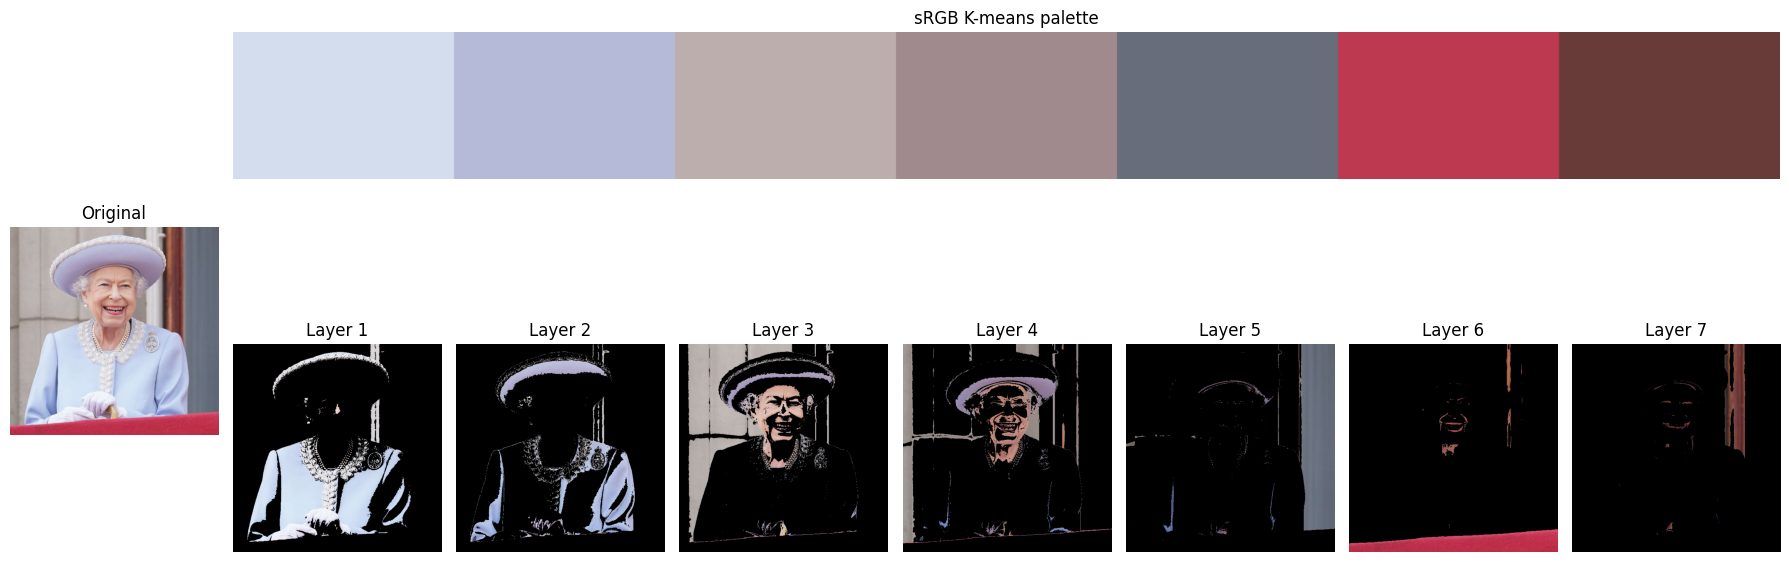

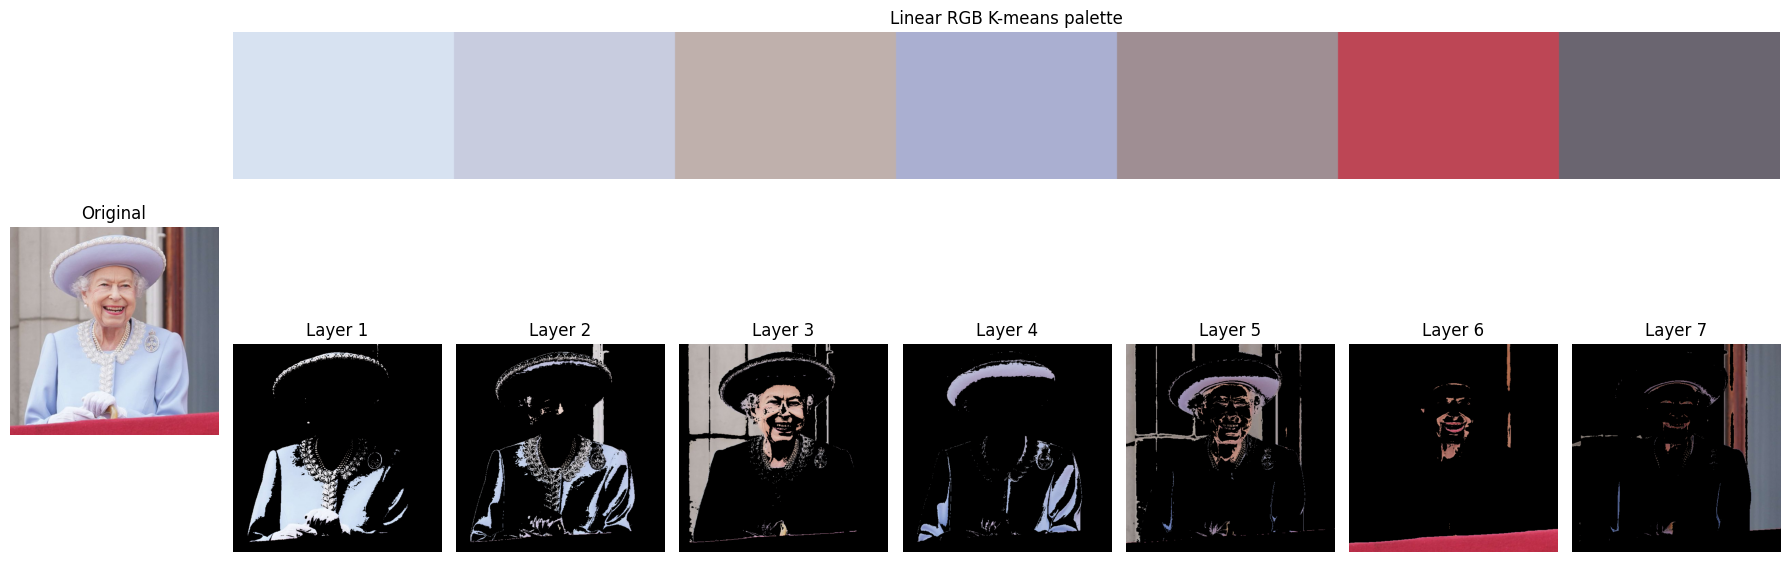

--- Reconstruction error ---
sRGB palette decomposition MSE:       0.0000e+00
Linear RGB palette decomposition MSE: 0.0000e+00


In [17]:
display_palette_result(
    array_queen_srgb,
    palette_strip_srgb,
    layers_srgb,
    title="sRGB K-means palette"
)

display_palette_result(
    array_queen_srgb,
    palette_strip_linear,
    layers_linear,
    title="Linear RGB K-means palette"
)

print("--- Reconstruction error ---")
print(f"sRGB palette decomposition MSE:       {reconstruction_error_srgb:.4e}")
print(f"Linear RGB palette decomposition MSE: {reconstruction_error_linear:.4e}")

### 1.2 CIELab Color Palette
You may have noticed that some clusters in your color palette are featuring colors that are quite different from each other, making editing a bit difficult. This is due sRGB not being a perceptually-uniform color space, which makes perceived and numerical differences between colors differ greatly. Perceptually uniform color spaces, such as CIELab, exploit computational models of human perception to create color spaces where geometric distances roughly correspond to similar distances in the perceptual space. This should ensure better color separation in your palette (Figure 1).

Edit your palette generation algorithm to use CIELab color space. You may use existing MATLAB/Python functions to translate your image from sRGB to CIELab. Compare both methods.

You can now edit the artistic look of your image intuitively by changing the individual color layers! Play around with them and generate some results of your own. You can try shifting the hue of specific layers, or plainly increasing lightness or saturation for specific effects. You should try it in at least 1 image of your own choice. Include the produced palette and filtered layers of the provided `queen.jpg` image as well.

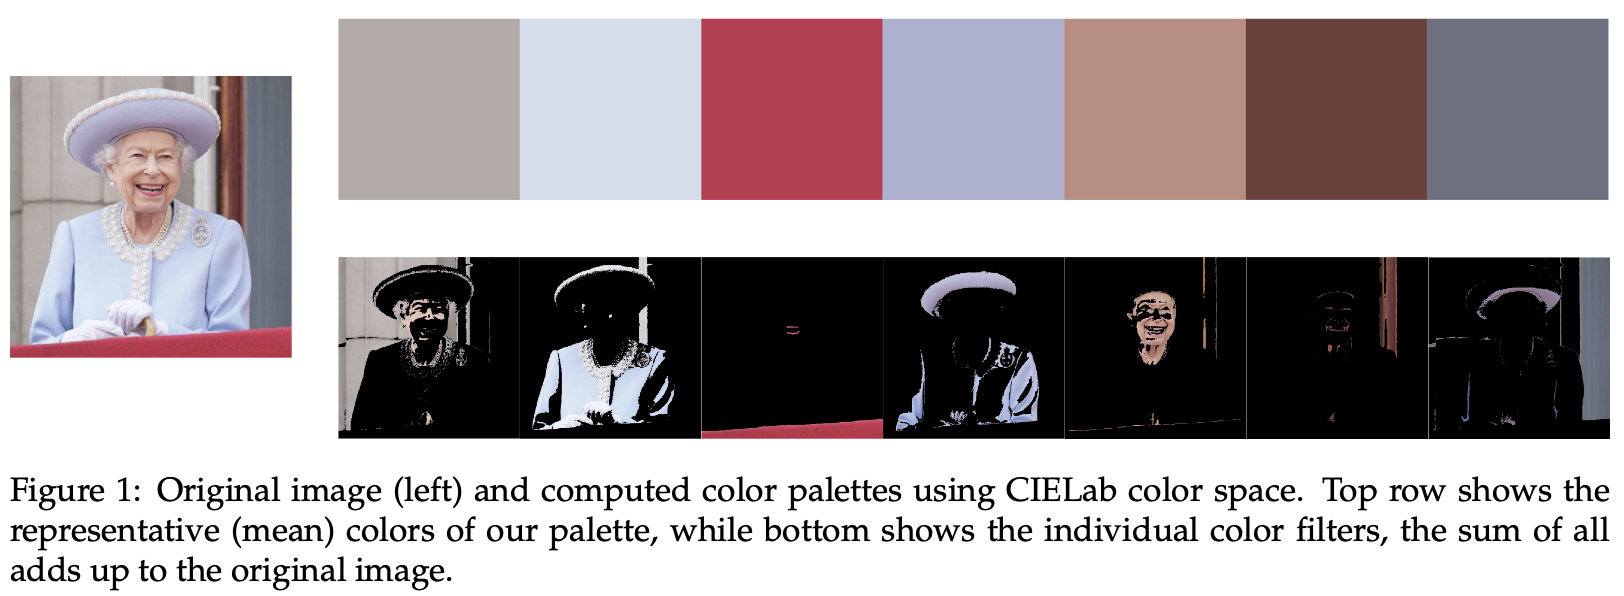


**Bonus [1.5 Points]:** An important tool when editing the colors and overall feel of an image is white balance. As we saw in Assignment #1, obtaining a neutral, calibrated white balance is important for accurate photographic reproduction, but we can also alter it for artistic purposes. Recover your white balance code from Assignment #1 and try increasing or decreasing the temperature of your image after computing your color palette. Try then combining it with your palette-based color editing and other simple point operations we saw in Assignment #1 (contrast, brightness) to create your own tiny Lightroom! Showcase it with a picture of your choice.

In [18]:
def rgb_to_lab(image_rgb: np.ndarray) -> np.ndarray:
    """Convert RGB image in [0, 1] to CIELab color space.

    OpenCV expects float RGB values in [0, 1].
    The resulting Lab image has L approximately in [0, 100],
    while a and b are approximately in [-128, 127].
    """
    image_rgb = np.clip(image_rgb, 0, 1).astype(np.float32)
    lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    return lab


def lab_to_rgb(lab_image: np.ndarray) -> np.ndarray:
    """Convert CIELab image back to RGB in [0, 1]."""
    lab_image = lab_image.astype(np.float32)
    rgb = cv2.cvtColor(lab_image, cv2.COLOR_LAB2RGB)
    return np.clip(rgb, 0, 1)


def lab_centers_to_rgb(centers_lab: np.ndarray) -> np.ndarray:
    """Convert K x 3 Lab cluster centers to RGB colors for visualization."""
    centers_lab_image = centers_lab.reshape(1, -1, 3).astype(np.float32)
    centers_rgb = lab_to_rgb(centers_lab_image).reshape(-1, 3)
    return np.clip(centers_rgb, 0, 1)


def compute_lab_palette(
        image_rgb: np.ndarray,
        n_clusters: int = 7,
        attempts: int = 5,
        seed: int = 0
) -> tuple[np.ndarray, np.ndarray, np.ndarray, list[np.ndarray], np.ndarray]:
    """Compute color palette and layers using K-means in CIELab color space.

    Returns:
        labels_lab: cluster labels for every pixel.
        centers_lab: cluster centers in CIELab space.
        centers_rgb: cluster centers converted to RGB for display.
        layers_rgb: decomposed RGB image layers.
        palette_strip_rgb: horizontal RGB palette strip.
    """
    image_lab = rgb_to_lab(image_rgb)

    labels_lab, centers_lab = kmeans_colors(
        image_lab,
        n_clusters=n_clusters,
        attempts=attempts,
        seed=seed
    )

    centers_rgb = lab_centers_to_rgb(centers_lab)

    labels_lab, centers_rgb = sort_palette_by_luminance(
        centers_rgb,
        labels_lab
    )

    layers_rgb = decompose_into_color_layers(
        image_rgb,
        labels_lab,
        n_clusters=n_clusters
    )

    palette_strip_rgb = make_palette_strip(centers_rgb)

    return labels_lab, centers_lab, centers_rgb, layers_rgb, palette_strip_rgb


def edit_layer_hls(
        layer_rgb: np.ndarray,
        hue_shift: float = 0.0,
        lightness_scale: float = 1.0,
        saturation_scale: float = 1.0
) -> np.ndarray:
    """Edit one RGB layer in HLS color space.

    hue_shift is given in degrees.
    lightness_scale > 1 makes the layer lighter.
    saturation_scale > 1 makes the layer more saturated.
    """
    layer_rgb = np.clip(layer_rgb, 0, 1).astype(np.float32)

    mask = layer_rgb.sum(axis=2) > 0

    hls = cv2.cvtColor(layer_rgb, cv2.COLOR_RGB2HLS)

    hls_edited = hls.copy()
    hls_edited[..., 0][mask] = (hls_edited[..., 0][mask] + hue_shift) % 360
    hls_edited[..., 1][mask] = np.clip(hls_edited[..., 1][mask] * lightness_scale, 0, 1)
    hls_edited[..., 2][mask] = np.clip(hls_edited[..., 2][mask] * saturation_scale, 0, 1)

    edited_rgb = cv2.cvtColor(hls_edited, cv2.COLOR_HLS2RGB)
    edited_rgb[~mask] = 0

    return np.clip(edited_rgb, 0, 1)


def edit_color_layers_hls(
        layers_rgb: list[np.ndarray],
        edits: dict[int, dict]
) -> tuple[list[np.ndarray], np.ndarray]:
    """Apply HLS edits to selected layers and reconstruct the final image.

    edits example:
        {
            2: {"hue_shift": 15, "lightness_scale": 1.1, "saturation_scale": 1.3},
            5: {"lightness_scale": 0.8}
        }
    """
    edited_layers = []

    for i, layer in enumerate(layers_rgb):
        if i in edits:
            edited_layer = edit_layer_hls(layer, **edits[i])
        else:
            edited_layer = layer.copy()

        edited_layers.append(edited_layer)

    edited_image = np.clip(np.sum(edited_layers, axis=0), 0, 1)

    return edited_layers, edited_image


def display_editing_result(
        original_rgb: np.ndarray,
        edited_rgb: np.ndarray,
        original_layers: list[np.ndarray],
        edited_layers: list[np.ndarray],
        title: str
):
    """Display original image, edited image, and edited color layers."""
    n_layers = len(original_layers)

    fig = plt.figure(figsize=(18, 8))
    grid = fig.add_gridspec(
        2,
        n_layers + 2,
        width_ratios=[1, 1] + [1] * n_layers
    )

    ax_original = fig.add_subplot(grid[:, 0])
    display(original_rgb, title="Original", ax=ax_original)

    ax_edited = fig.add_subplot(grid[:, 1])
    display(edited_rgb, title="Edited image", ax=ax_edited)

    for i, layer in enumerate(edited_layers):
        ax = fig.add_subplot(grid[0, i + 2])
        display(original_layers[i], title=f"Original layer {i + 1}", ax=ax)

        ax = fig.add_subplot(grid[1, i + 2])
        display(layer, title=f"Edited layer {i + 1}", ax=ax)

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

In [19]:
# Load image
image_queen = load_rgb_image("./queen.jpg")
array_queen_srgb = image2array(image_queen)

n_clusters = 7

# --- sRGB palette from Task 1.1 ---
labels_srgb, centers_srgb = kmeans_colors(
    array_queen_srgb,
    n_clusters=n_clusters,
    attempts=5,
    seed=42
)

labels_srgb, centers_srgb = sort_palette_by_luminance(
    centers_srgb,
    labels_srgb
)

layers_srgb = decompose_into_color_layers(
    array_queen_srgb,
    labels_srgb,
    n_clusters=n_clusters
)

palette_strip_srgb = make_palette_strip(centers_srgb)


# --- CIELab palette ---
labels_lab, centers_lab, centers_lab_rgb, layers_lab, palette_strip_lab = compute_lab_palette(
    array_queen_srgb,
    n_clusters=n_clusters,
    attempts=5,
    seed=42
)


# --- Artistic editing using CIELab layers ---
# These layer ids may be adjusted after looking at the displayed decomposition.
queen_layer_edits = {
    1: {
        "hue_shift": -10,
        "lightness_scale": 1.10,
        "saturation_scale": 1.15
    },
    2: {
        "hue_shift": 12,
        "lightness_scale": 1.00,
        "saturation_scale": 1.25
    },
    4: {
        "hue_shift": 0,
        "lightness_scale": 1.15,
        "saturation_scale": 1.05
    },
    5: {
        "hue_shift": 5,
        "lightness_scale": 0.90,
        "saturation_scale": 1.20
    }
}

edited_layers_lab, edited_queen_lab = edit_color_layers_hls(
    layers_lab,
    queen_layer_edits
)


# Reconstruction check
reconstructed_lab = np.sum(layers_lab, axis=0)
reconstruction_error_lab = np.mean((array_queen_srgb - reconstructed_lab) ** 2)

###  <span style="color:orange">  </span>
<span style="color:orange"> **Report.** _Report your results here._ </span>

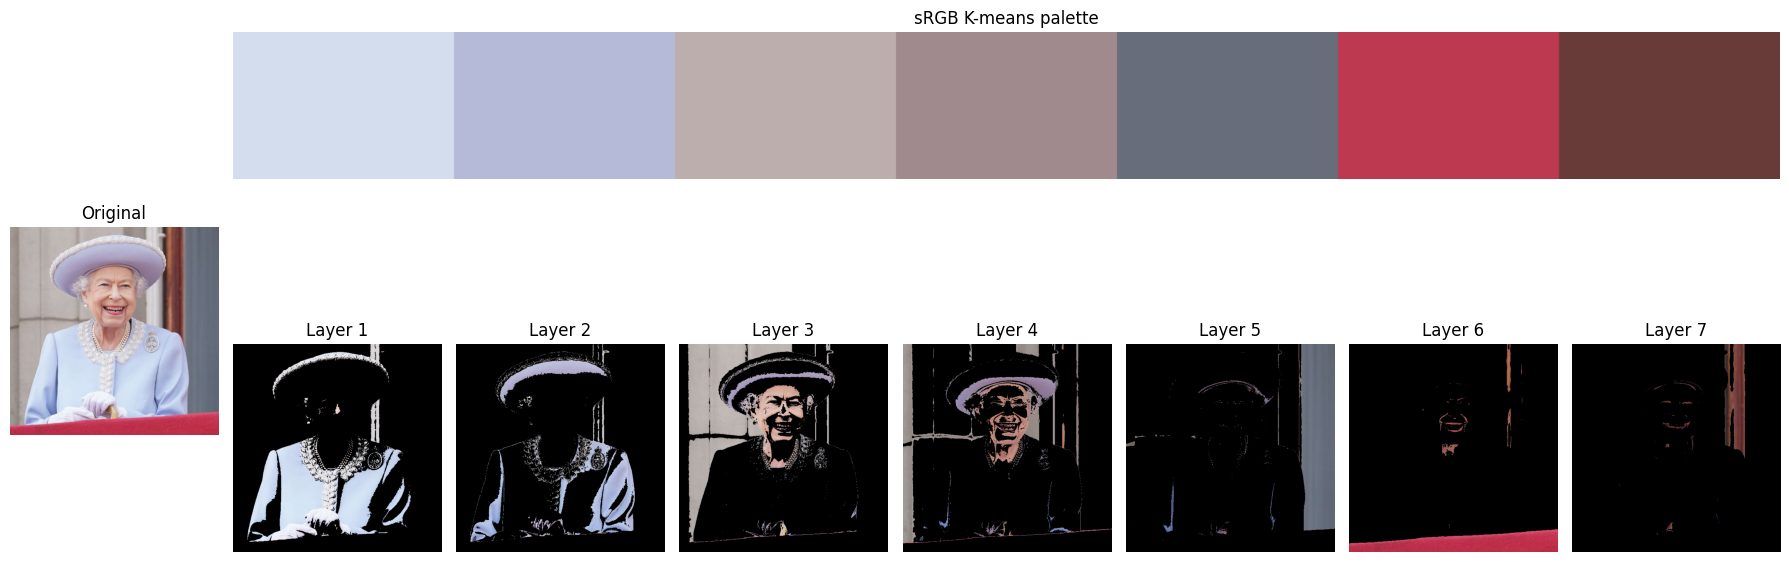

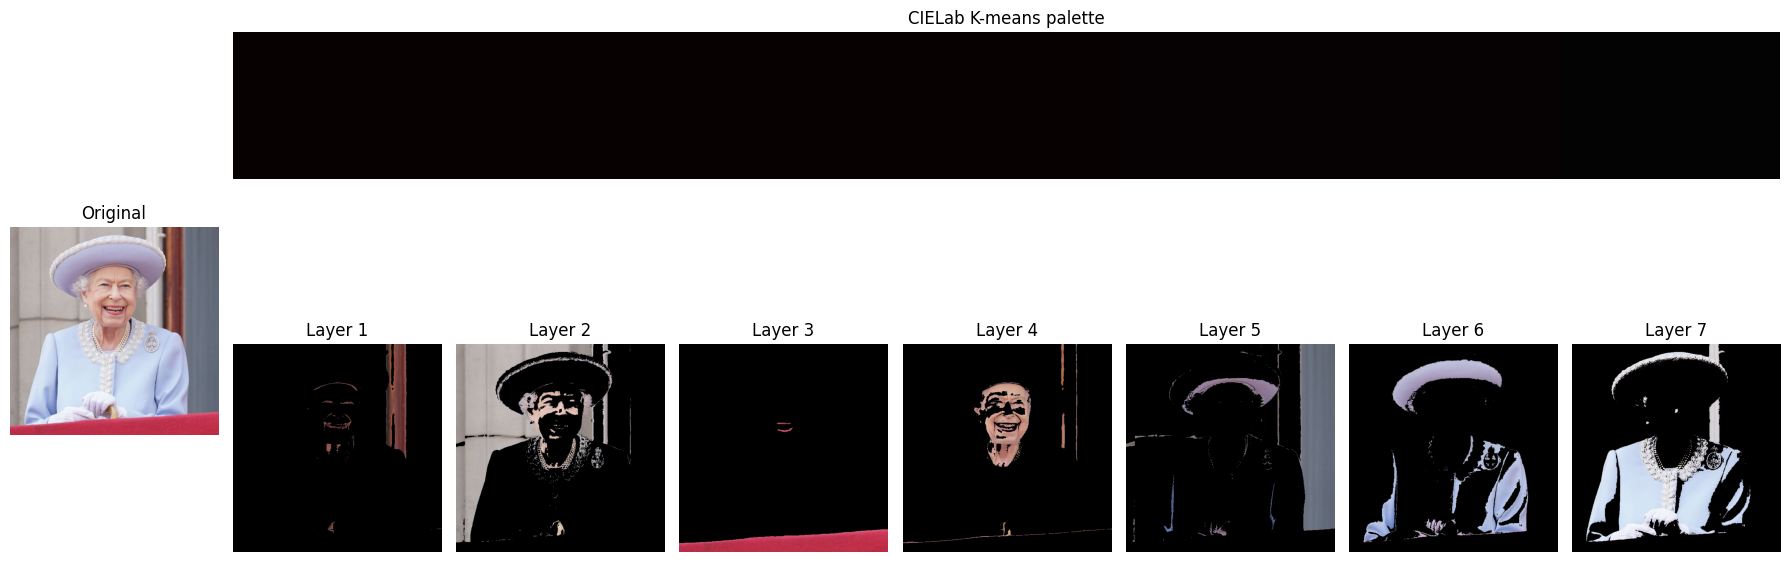

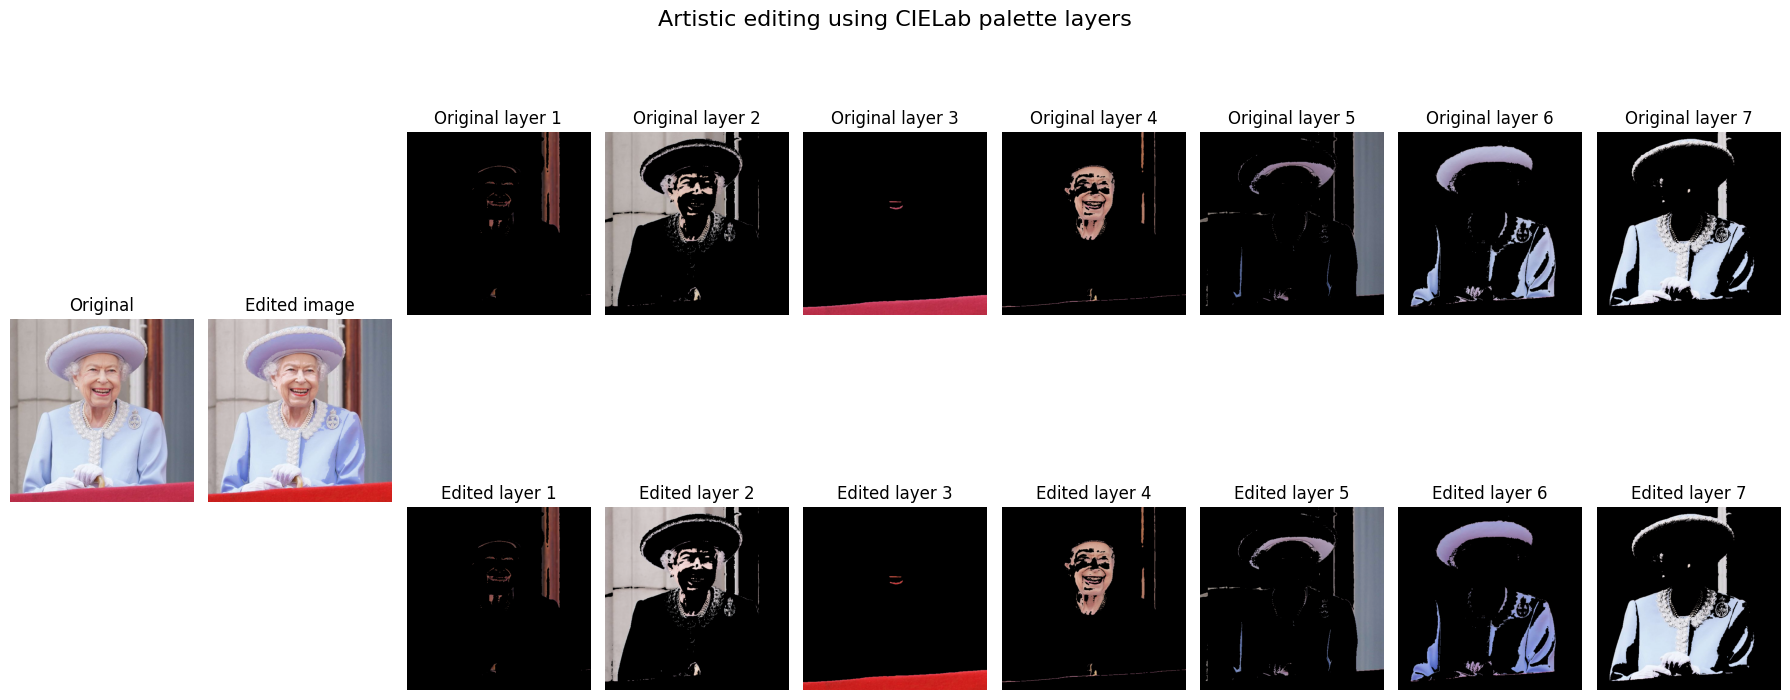

--- Reconstruction error ---
CIELab palette decomposition MSE: 0.0000e+00


In [20]:
display_palette_result(
    array_queen_srgb,
    palette_strip_srgb,
    layers_srgb,
    title="sRGB K-means palette"
)

display_palette_result(
    array_queen_srgb,
    palette_strip_lab,
    layers_lab,
    title="CIELab K-means palette"
)

display_editing_result(
    array_queen_srgb,
    edited_queen_lab,
    layers_lab,
    edited_layers_lab,
    title="Artistic editing using CIELab palette layers"
)

print("--- Reconstruction error ---")
print(f"CIELab palette decomposition MSE: {reconstruction_error_lab:.4e}")

## 2 Color Quantization and Lookup Tables (LUTs) [4 Points]
Quantization and color mapping through LUTs are techniques used in image processing to transform the color space of an image, either to reduce the amount of data required to represent the image, or to map colors from one space to another.

Quantization involves reducing the number of colors in an image by mapping similar colors to a smaller set of discrete values. This can be done by dividing the color space into a regular grid, and assigning each pixel to the closest grid point. This process is commonly used in image compression, as it reduces the amount of data required to represent the image, by storing per-pixel color IDs instead of exact colors. However, it can also cause loss of detail and introduce visual artifacts.

LUTs are used to map one set of values to another set of values. In image processing, LUTs are commonly used to map colors from one color space to another. For example, they can be used to convert an RGB image to a grayscale image, by mapping each pixel’s RGB values to a specific grayscale value. LUTs are also widely used in cinema production to apply color grading effects to an image or video, by mapping the original colors to new, adjusted colors, to achieve specific artistic effects.

**Task.** Implement a basic quantization method to reduce the size of the provided image by mapping its pixel values to a set of 32 colors. You may use any method to constrain this color space, except pre-defined MATLAB/Python solutions, of course. A few suggestions are, but not limited to: color clipping, thresholding, clustering, palette-based or euclidean distance-based nearest neighbors. Then, implement a look-up table that transforms your compressed RGB image into a grayscale image. You are also free to choose any method to map your 32 quantized colors to grey values, taking luminance, color difference or hue into account, for example. Try to maximize perceived quality, and make sure to explain in detail your approach for both quantization and LUT color mapping in you report. Show both your quantized color image and your resulting grayscale image after applying your LUT in the provided `queen.jpg` image.

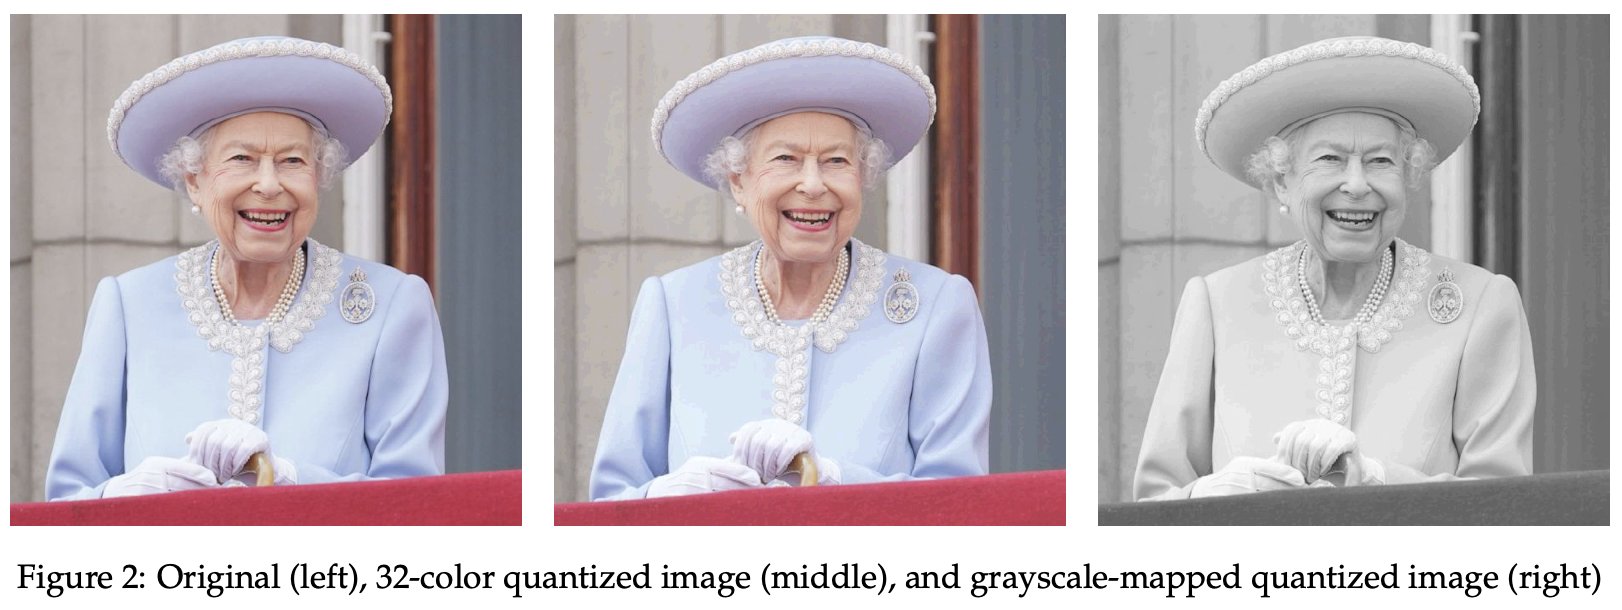

**Bonus [1.5 Points]:** Make your color quantization pipeline perceptually-aware, by exploiting human color and luminance perception to quantize colors more aggressively or making quantization less obvious. Use the Weber-Fechner Law and perceptual color models like CAM or CIELab to improve quantization. Show this improvement comparatively.

In [21]:
def fit_kmeans_centers(
        features: np.ndarray,
        n_clusters: int = 32,
        attempts: int = 5,
        seed: int = 0,
        sample_size: int | None = None
) -> np.ndarray:
    """Fit K-means centers on a set of feature vectors.

    The function is general and can be used both for RGB features and CIELab features.
    It does not clip the centers, because Lab values are not limited to [0, 1].
    """
    features = features.astype(np.float32)

    if sample_size is not None and len(features) > sample_size:
        rng = np.random.default_rng(seed)
        sample_ids = rng.choice(len(features), size=sample_size, replace=False)
        features_for_kmeans = features[sample_ids]
    else:
        features_for_kmeans = features

    cv2.setRNGSeed(seed)

    criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        100,
        1e-4
    )

    _, _, centers = cv2.kmeans(
        features_for_kmeans,
        n_clusters,
        None,
        criteria,
        attempts,
        cv2.KMEANS_PP_CENTERS
    )

    return centers.astype(np.float32)


def assign_nearest_centers(
        features: np.ndarray,
        centers: np.ndarray,
        chunk_size: int = 200_000
) -> np.ndarray:
    """Assign every feature vector to the nearest K-means center."""
    features = features.astype(np.float32)
    centers = centers.astype(np.float32)

    labels = np.zeros(len(features), dtype=np.int32)

    for start in range(0, len(features), chunk_size):
        end = min(start + chunk_size, len(features))
        chunk = features[start:end]

        distances = np.sum(
            (chunk[:, None, :] - centers[None, :, :]) ** 2,
            axis=2
        )

        labels[start:end] = np.argmin(distances, axis=1)

    return labels


def rgb_to_lab(image_rgb: np.ndarray) -> np.ndarray:
    """Convert RGB image in [0, 1] to CIELab color space."""
    image_rgb = np.clip(image_rgb, 0, 1).astype(np.float32)
    return cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)


def lab_to_rgb(image_lab: np.ndarray) -> np.ndarray:
    """Convert CIELab image to RGB in [0, 1]."""
    image_lab = image_lab.astype(np.float32)
    image_rgb = cv2.cvtColor(image_lab, cv2.COLOR_LAB2RGB)
    return np.clip(image_rgb, 0, 1)


def lab_palette_to_rgb(palette_lab: np.ndarray) -> np.ndarray:
    """Convert K x 3 Lab palette to K x 3 RGB palette."""
    palette_lab_image = palette_lab.reshape(1, -1, 3)
    palette_rgb = lab_to_rgb(palette_lab_image).reshape(-1, 3)
    return np.clip(palette_rgb, 0, 1)


def rgb_luminance(colors_rgb: np.ndarray) -> np.ndarray:
    """Compute perceptual luminance from RGB colors.

    We use Rec. 709 luminance weights instead of a simple channel average.
    """
    colors_rgb = np.clip(colors_rgb, 0, 1)

    return (
        0.2126 * colors_rgb[..., 0] +
        0.7152 * colors_rgb[..., 1] +
        0.0722 * colors_rgb[..., 2]
    )


def sort_quantization_by_luminance(
        labels: np.ndarray,
        centers: np.ndarray,
        palette_rgb: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Sort palette colors from bright to dark and remap labels."""
    luminance = rgb_luminance(palette_rgb)

    order = np.argsort(-luminance)
    inverse_order = np.zeros_like(order)
    inverse_order[order] = np.arange(len(order))

    sorted_labels = inverse_order[labels]
    sorted_centers = centers[order]
    sorted_palette_rgb = palette_rgb[order]

    return sorted_labels, sorted_centers, sorted_palette_rgb


def quantize_rgb_kmeans(
        image_rgb: np.ndarray,
        n_colors: int = 32,
        attempts: int = 5,
        seed: int = 0,
        sample_size: int | None = None
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Quantize an image to n_colors using K-means in RGB space.

    Returns:
        labels_image: H x W image of palette indices.
        palette_rgb: n_colors x 3 palette in RGB.
        quantized_rgb: H x W x 3 quantized RGB image.
    """
    h, w, _ = image_rgb.shape

    features_rgb = image_rgb.reshape(-1, 3).astype(np.float32)

    centers_rgb = fit_kmeans_centers(
        features_rgb,
        n_clusters=n_colors,
        attempts=attempts,
        seed=seed,
        sample_size=sample_size
    )

    labels = assign_nearest_centers(features_rgb, centers_rgb)
    labels_image = labels.reshape(h, w)

    palette_rgb = np.clip(centers_rgb, 0, 1)

    labels_image, _, palette_rgb = sort_quantization_by_luminance(
        labels_image,
        palette_rgb,
        palette_rgb
    )

    quantized_rgb = palette_rgb[labels_image]

    return labels_image, palette_rgb, quantized_rgb


def quantize_lab_kmeans(
        image_rgb: np.ndarray,
        n_colors: int = 32,
        attempts: int = 5,
        seed: int = 0,
        sample_size: int | None = None
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Quantize an image to n_colors using K-means in CIELab space.

    This is the perceptually-aware version, because distances in CIELab are closer
    to perceived color differences than distances in RGB.
    """
    h, w, _ = image_rgb.shape

    image_lab = rgb_to_lab(image_rgb)
    features_lab = image_lab.reshape(-1, 3).astype(np.float32)

    centers_lab = fit_kmeans_centers(
        features_lab,
        n_clusters=n_colors,
        attempts=attempts,
        seed=seed,
        sample_size=sample_size
    )

    labels = assign_nearest_centers(features_lab, centers_lab)
    labels_image = labels.reshape(h, w)

    palette_rgb = lab_palette_to_rgb(centers_lab)

    labels_image, centers_lab, palette_rgb = sort_quantization_by_luminance(
        labels_image,
        centers_lab,
        palette_rgb
    )

    quantized_rgb = palette_rgb[labels_image]

    return labels_image, palette_rgb, quantized_rgb


def make_grayscale_lut_from_palette(palette_rgb: np.ndarray) -> np.ndarray:
    """Create LUT that maps palette index to grayscale luminance value."""
    grayscale_values = rgb_luminance(palette_rgb)
    return np.clip(grayscale_values, 0, 1)


def apply_grayscale_lut(labels_image: np.ndarray, grayscale_lut: np.ndarray) -> np.ndarray:
    """Map compressed palette-index image to a grayscale image using LUT."""
    grayscale_image = grayscale_lut[labels_image]
    return np.clip(grayscale_image, 0, 1)


def make_palette_strip(
        palette_rgb: np.ndarray,
        height: int = 50,
        width_per_color: int = 24
) -> np.ndarray:
    """Create horizontal visualization of palette colors."""
    n_colors = len(palette_rgb)

    strip = np.zeros(
        (height, width_per_color * n_colors, 3),
        dtype=np.float32
    )

    for i, color in enumerate(palette_rgb):
        x0 = i * width_per_color
        x1 = (i + 1) * width_per_color
        strip[:, x0:x1] = color

    return strip


def image_mse(image_a: np.ndarray, image_b: np.ndarray) -> float:
    """Compute mean squared error between two images."""
    return float(np.mean((image_a - image_b) ** 2))


def image_psnr(image_a: np.ndarray, image_b: np.ndarray) -> float:
    """Compute PSNR between two images in [0, 1]."""
    mse = image_mse(image_a, image_b)

    if mse == 0:
        return float("inf")

    return float(10 * np.log10(1.0 / mse))


def mean_delta_e76(image_a_rgb: np.ndarray, image_b_rgb: np.ndarray) -> float:
    """Compute average CIELab distance between two RGB images."""
    lab_a = rgb_to_lab(image_a_rgb).reshape(-1, 3)
    lab_b = rgb_to_lab(image_b_rgb).reshape(-1, 3)

    delta_e = np.linalg.norm(lab_a - lab_b, axis=1)
    return float(np.mean(delta_e))


def display_quantization_result(
        original_rgb: np.ndarray,
        quantized_rgb: np.ndarray,
        grayscale_image: np.ndarray,
        palette_rgb: np.ndarray,
        title: str
):
    """Display original image, quantized image, grayscale LUT result, and palette."""
    palette_strip = make_palette_strip(palette_rgb)

    fig = plt.figure(figsize=(16, 6))
    grid = fig.add_gridspec(2, 3, height_ratios=[4, 1])

    ax = fig.add_subplot(grid[0, 0])
    ax.imshow(np.clip(original_rgb, 0, 1))
    ax.set_title("Original")
    ax.axis("off")

    ax = fig.add_subplot(grid[0, 1])
    ax.imshow(np.clip(quantized_rgb, 0, 1))
    ax.set_title("32-color quantized")
    ax.axis("off")

    ax = fig.add_subplot(grid[0, 2])
    ax.imshow(np.clip(grayscale_image, 0, 1), cmap="gray", vmin=0, vmax=1)
    ax.set_title("Grayscale after LUT")
    ax.axis("off")

    ax = fig.add_subplot(grid[1, :])
    ax.imshow(np.clip(palette_strip, 0, 1))
    ax.set_title("32-color palette")
    ax.axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


def print_lut_table(
        palette_rgb: np.ndarray,
        grayscale_lut: np.ndarray,
        title: str,
        max_rows: int = 32
):
    """Print palette-index to grayscale LUT."""
    print(title)
    print("index | palette RGB uint8 | grayscale uint8")
    print("-------------------------------------------")

    palette_uint8 = np.round(np.clip(palette_rgb, 0, 1) * 255).astype(np.uint8)
    gray_uint8 = np.round(np.clip(grayscale_lut, 0, 1) * 255).astype(np.uint8)

    for i in range(min(len(grayscale_lut), max_rows)):
        rgb_tuple = tuple(palette_uint8[i])
        print(f"{i:>5} | {rgb_tuple!s:<17} | {gray_uint8[i]:>14}")

In [22]:
# Load image
image_queen = load_rgb_image("./queen.jpg")
array_queen_srgb = image2array(image_queen)

n_colors = 32

# --- Basic RGB-space quantization ---
labels_rgb_32, palette_rgb_32, quantized_rgb_32 = quantize_rgb_kmeans(
    array_queen_srgb,
    n_colors=n_colors,
    attempts=5,
    seed=42,
    sample_size=None
)

lut_rgb_32 = make_grayscale_lut_from_palette(palette_rgb_32)
grayscale_rgb_32 = apply_grayscale_lut(labels_rgb_32, lut_rgb_32)

compressed_rgb_32 = {
    "labels": labels_rgb_32.astype(np.uint8),
    "palette": palette_rgb_32.astype(np.float32)
}


# --- Bonus: perceptually-aware CIELab quantization ---
labels_lab_32, palette_lab_32, quantized_lab_32 = quantize_lab_kmeans(
    array_queen_srgb,
    n_colors=n_colors,
    attempts=5,
    seed=42,
    sample_size=None
)

lut_lab_32 = make_grayscale_lut_from_palette(palette_lab_32)
grayscale_lab_32 = apply_grayscale_lut(labels_lab_32, lut_lab_32)

compressed_lab_32 = {
    "labels": labels_lab_32.astype(np.uint8),
    "palette": palette_lab_32.astype(np.float32)
}


# --- Quantitative comparison ---
mse_rgb_32 = image_mse(array_queen_srgb, quantized_rgb_32)
psnr_rgb_32 = image_psnr(array_queen_srgb, quantized_rgb_32)
delta_e_rgb_32 = mean_delta_e76(array_queen_srgb, quantized_rgb_32)

mse_lab_32 = image_mse(array_queen_srgb, quantized_lab_32)
psnr_lab_32 = image_psnr(array_queen_srgb, quantized_lab_32)
delta_e_lab_32 = mean_delta_e76(array_queen_srgb, quantized_lab_32)# Execute your code here

###  <span style="color:orange">  </span>
<span style="color:orange"> **Report.** _Report your results here._ </span>

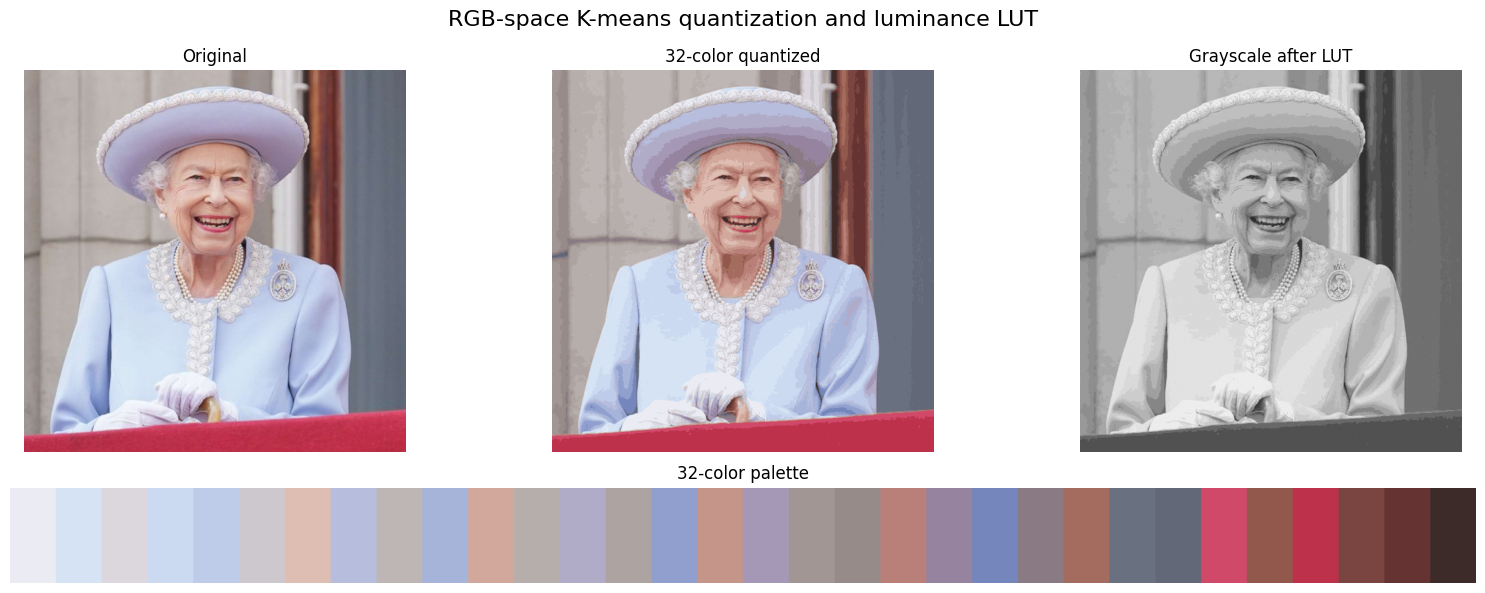

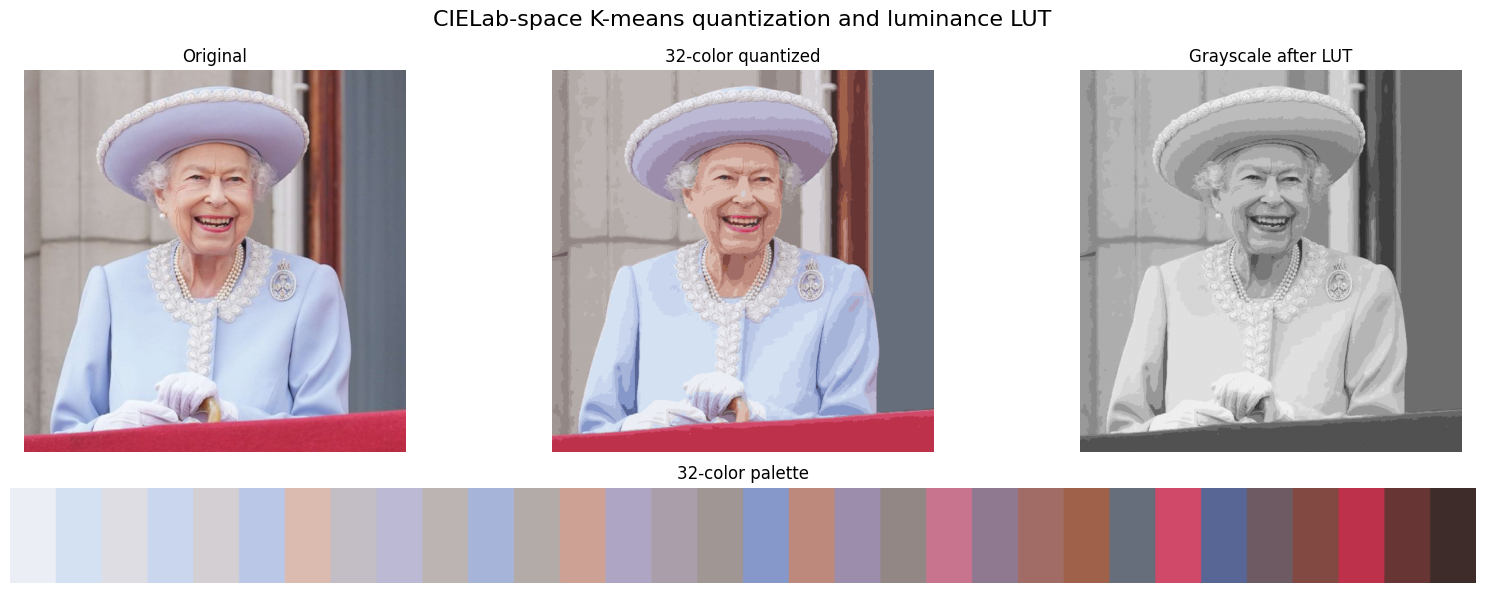

--- Quantization quality comparison ---
RGB K-means  | MSE: 0.000436 | PSNR: 33.60 dB | mean Delta E: 2.92
Lab K-means  | MSE: 0.000602 | PSNR: 32.20 dB | mean Delta E: 2.74

LUT used for the perceptually-aware Lab quantized image
index | palette RGB uint8 | grayscale uint8
-------------------------------------------
    0 | (np.uint8(237), np.uint8(238), np.uint8(245)) |            238
    1 | (np.uint8(211), np.uint8(226), np.uint8(243)) |            224
    2 | (np.uint8(224), np.uint8(222), np.uint8(229)) |            223
    3 | (np.uint8(201), np.uint8(215), np.uint8(239)) |            213
    4 | (np.uint8(211), np.uint8(207), np.uint8(211)) |            208
    5 | (np.uint8(187), np.uint8(200), np.uint8(231)) |            199
    6 | (np.uint8(220), np.uint8(188), np.uint8(176)) |            194
    7 | (np.uint8(195), np.uint8(190), np.uint8(197)) |            192
    8 | (np.uint8(187), np.uint8(186), np.uint8(212)) |            188
    9 | (np.uint8(189), np.uint8(181), np.

In [23]:
display_quantization_result(
    array_queen_srgb,
    quantized_rgb_32,
    grayscale_rgb_32,
    palette_rgb_32,
    title="RGB-space K-means quantization and luminance LUT"
)

display_quantization_result(
    array_queen_srgb,
    quantized_lab_32,
    grayscale_lab_32,
    palette_lab_32,
    title="CIELab-space K-means quantization and luminance LUT"
)

print("--- Quantization quality comparison ---")
print(f"RGB K-means  | MSE: {mse_rgb_32:.6f} | PSNR: {psnr_rgb_32:.2f} dB | mean Delta E: {delta_e_rgb_32:.2f}")
print(f"Lab K-means  | MSE: {mse_lab_32:.6f} | PSNR: {psnr_lab_32:.2f} dB | mean Delta E: {delta_e_lab_32:.2f}")

print()
print_lut_table(
    palette_lab_32,
    lut_lab_32,
    title="LUT used for the perceptually-aware Lab quantized image"
)

## 3 Gaussian and Laplacian Pyramids [5 Points]
Multi-scale image representations (also called pyramids) transform an image into a set of images representing different frequency bands in the original image. While a Gaussian pyramid stores different low-pass versions of the original image, every level of Laplacian pyramid stores a specific range of spatial frequencies which correspond to band-passed versions of the original images. When all levels of Laplacian pyramid are added the result is the original image. This is not true for Gaussian pyramids.

**Task.** Implement a function to compute a Laplacian pyramid of an input image. The code should decompose the image into 4 levels. You are allowed to use MATLAB/Python functions for spatial filtering and resizing images. The most straightforward way to realize this task is to first build the Gaussian pyramid, and then subtract the consecutive levels to obtain the individual levels of the Laplacian pyramid (the procedure we described during the lecture). Compute the Laplacian pyramid of the two provided images (`sad.jpg` and `happy.jpg`) and show the different levels of your pyramid in your report.

In [24]:
def resize_to_shape(image: np.ndarray, target_shape: tuple[int, int]) -> np.ndarray:
    """Resize image to target height and width."""
    target_h, target_w = target_shape

    resized = cv2.resize(
        image,
        (target_w, target_h),
        interpolation=cv2.INTER_LINEAR
    )

    return resized


def build_gaussian_pyramid(
        image_rgb: np.ndarray,
        n_levels: int = 4
) -> list[np.ndarray]:
    """Build Gaussian pyramid.

    Level 0 is the original image. Each next level is blurred and downsampled.
    """
    pyramid = [np.clip(image_rgb, 0, 1).astype(np.float32)]

    for _ in range(1, n_levels):
        next_level = cv2.pyrDown(pyramid[-1])
        pyramid.append(next_level)

    return pyramid


def build_laplacian_pyramid(
        image_rgb: np.ndarray,
        n_levels: int = 4
) -> tuple[list[np.ndarray], list[np.ndarray]]:
    """Build Laplacian pyramid using a Gaussian pyramid.

    For n_levels=4, the output Laplacian pyramid contains:
        L0 = G0 - upsample(G1)
        L1 = G1 - upsample(G2)
        L2 = G2 - upsample(G3)
        L3 = G3

    The last level is the low-frequency residual.
    """
    gaussian_pyramid = build_gaussian_pyramid(
        image_rgb,
        n_levels=n_levels
    )

    laplacian_pyramid = []

    for i in range(n_levels - 1):
        current = gaussian_pyramid[i]
        next_level = gaussian_pyramid[i + 1]

        expanded = cv2.pyrUp(next_level)
        expanded = resize_to_shape(
            expanded,
            target_shape=current.shape[:2]
        )

        laplacian = current - expanded
        laplacian_pyramid.append(laplacian)

    laplacian_pyramid.append(gaussian_pyramid[-1])

    return gaussian_pyramid, laplacian_pyramid


def reconstruct_from_laplacian_pyramid(
        laplacian_pyramid: list[np.ndarray]
) -> np.ndarray:
    """Reconstruct image from Laplacian pyramid."""
    reconstruction = laplacian_pyramid[-1]

    for i in range(len(laplacian_pyramid) - 2, -1, -1):
        target_shape = laplacian_pyramid[i].shape[:2]

        reconstruction = cv2.pyrUp(reconstruction)
        reconstruction = resize_to_shape(
            reconstruction,
            target_shape=target_shape
        )

        reconstruction = reconstruction + laplacian_pyramid[i]

    return np.clip(reconstruction, 0, 1)


def normalize_laplacian_for_display(
        laplacian: np.ndarray,
        contrast: float = 4.0
) -> np.ndarray:
    """Convert signed Laplacian level to visible image.

    Laplacian levels contain positive and negative values, so direct display is not
    informative. We shift zero to 0.5 and amplify contrast.
    """
    visible = 0.5 + contrast * laplacian
    return np.clip(visible, 0, 1)


def display_gaussian_pyramid(
        gaussian_pyramid: list[np.ndarray],
        title: str
):
    """Display all Gaussian pyramid levels."""
    n_levels = len(gaussian_pyramid)

    fig, axes = plt.subplots(
        1,
        n_levels,
        figsize=(4 * n_levels, 4)
    )

    if n_levels == 1:
        axes = [axes]

    for i, level in enumerate(gaussian_pyramid):
        axes[i].imshow(np.clip(level, 0, 1))
        axes[i].set_title(f"G{i}: {level.shape[1]}×{level.shape[0]}")
        axes[i].axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


def display_laplacian_pyramid(
        laplacian_pyramid: list[np.ndarray],
        title: str,
        contrast: float = 4.0
):
    """Display all Laplacian pyramid levels."""
    n_levels = len(laplacian_pyramid)

    fig, axes = plt.subplots(
        1,
        n_levels,
        figsize=(4 * n_levels, 4)
    )

    if n_levels == 1:
        axes = [axes]

    for i, level in enumerate(laplacian_pyramid):
        if i < n_levels - 1:
            visible = normalize_laplacian_for_display(
                level,
                contrast=contrast
            )
            level_title = f"L{i}: band-pass"
        else:
            visible = np.clip(level, 0, 1)
            level_title = f"L{i}: low-pass residual"

        axes[i].imshow(visible)
        axes[i].set_title(level_title)
        axes[i].axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


def display_pyramid_reconstruction(
        original_rgb: np.ndarray,
        reconstructed_rgb: np.ndarray,
        title: str
):
    """Display original image, reconstruction, and absolute reconstruction error."""
    error_image = np.abs(original_rgb - reconstructed_rgb)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(14, 4)
    )

    axes[0].imshow(np.clip(original_rgb, 0, 1))
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(np.clip(reconstructed_rgb, 0, 1))
    axes[1].set_title("Reconstructed from Laplacian pyramid")
    axes[1].axis("off")

    axes[2].imshow(np.clip(error_image * 20, 0, 1))
    axes[2].set_title("Absolute error ×20")
    axes[2].axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


def pyramid_reconstruction_error(
        original_rgb: np.ndarray,
        reconstructed_rgb: np.ndarray
) -> float:
    """Compute MSE between original and reconstructed image."""
    return float(np.mean((original_rgb - reconstructed_rgb) ** 2))

In [25]:
# Load images
sad_image = load_rgb_image("./sad.jpg")
happy_image = load_rgb_image("./happy.jpg")

sad_rgb = image2array(sad_image)
happy_rgb = image2array(happy_image)

n_pyramid_levels = 4

# Build pyramids for sad.jpg
sad_gaussian_pyramid, sad_laplacian_pyramid = build_laplacian_pyramid(
    sad_rgb,
    n_levels=n_pyramid_levels
)

sad_reconstructed = reconstruct_from_laplacian_pyramid(
    sad_laplacian_pyramid
)

sad_reconstruction_mse = pyramid_reconstruction_error(
    sad_rgb,
    sad_reconstructed
)


# Build pyramids for happy.jpg
happy_gaussian_pyramid, happy_laplacian_pyramid = build_laplacian_pyramid(
    happy_rgb,
    n_levels=n_pyramid_levels
)

happy_reconstructed = reconstruct_from_laplacian_pyramid(
    happy_laplacian_pyramid
)

happy_reconstruction_mse = pyramid_reconstruction_error(
    happy_rgb,
    happy_reconstructed
)

###  <span style="color:orange">  </span>
<span style="color:orange"> **Report.** _Report your results here._ </span>

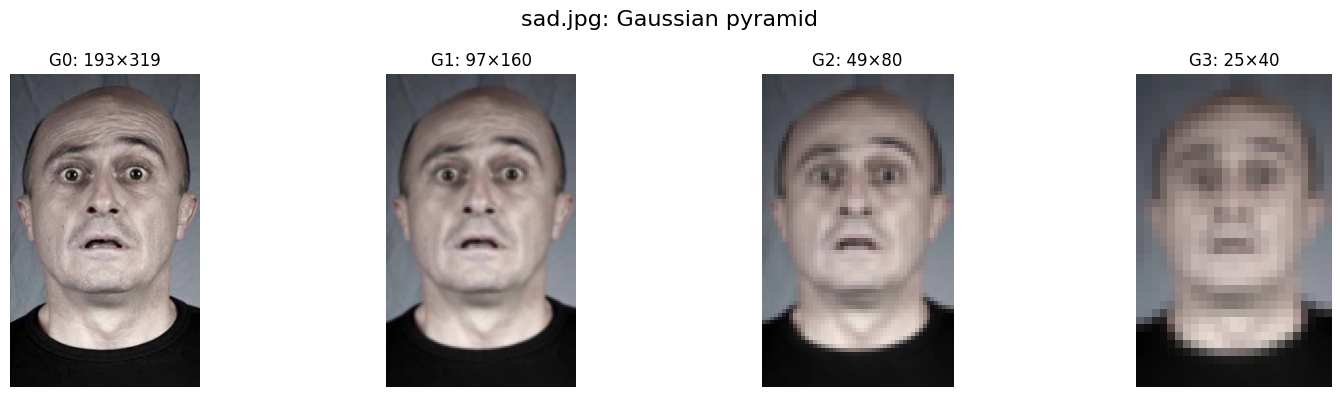

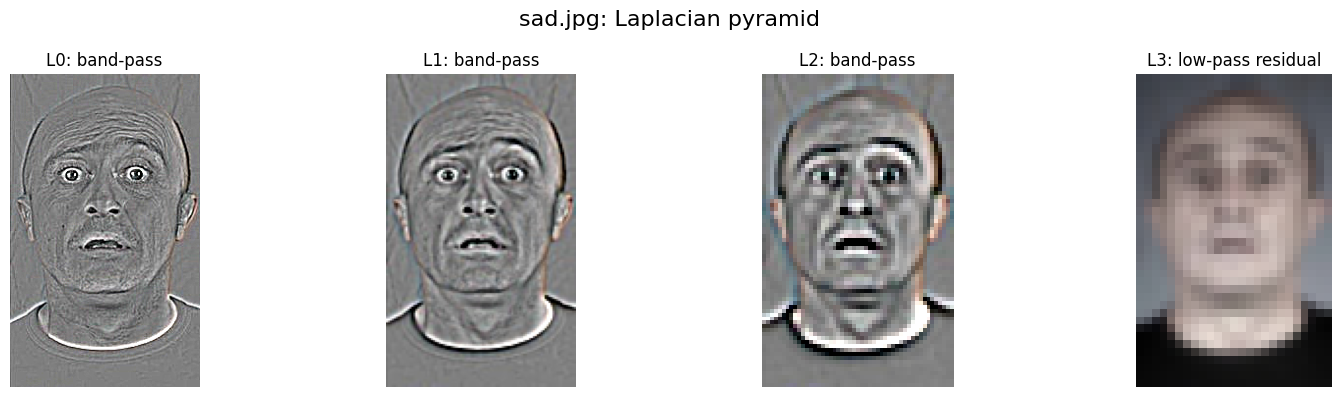

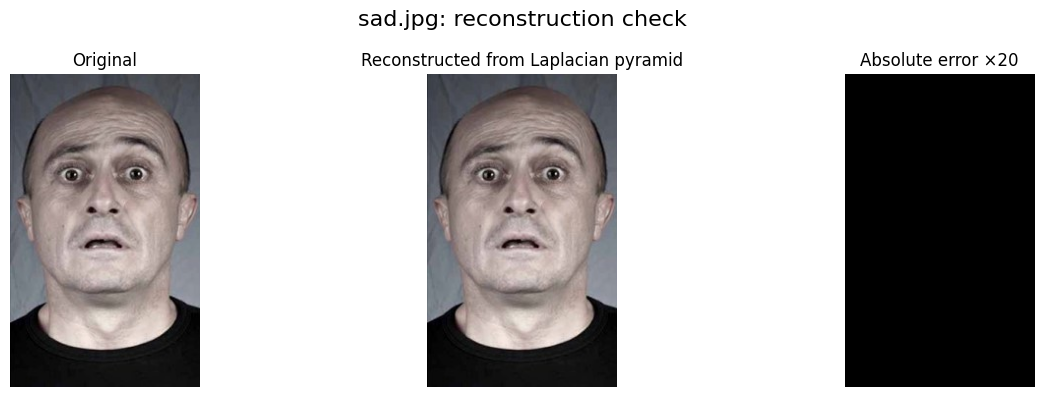

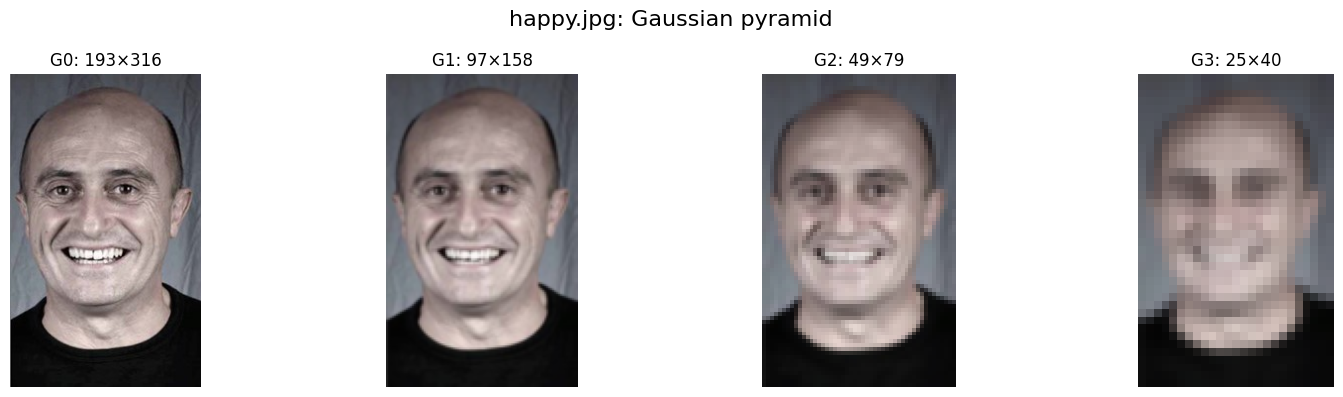

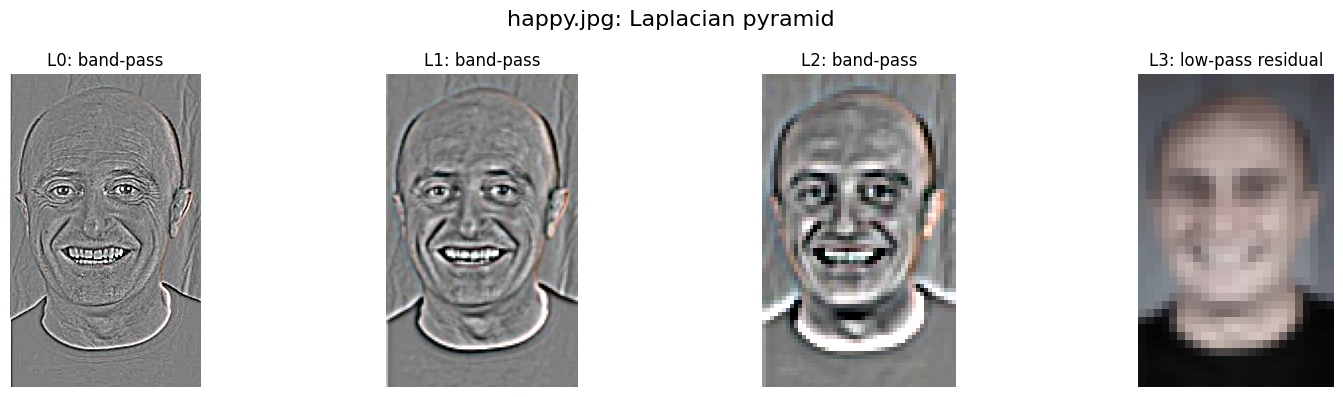

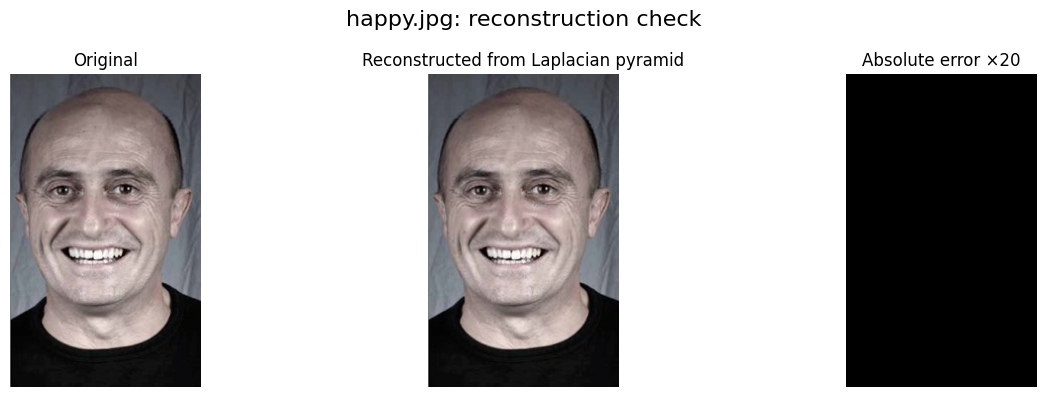

--- Reconstruction error ---
sad.jpg Laplacian reconstruction MSE:   8.521531e-19
happy.jpg Laplacian reconstruction MSE: 7.645011e-19


In [26]:
display_gaussian_pyramid(
    sad_gaussian_pyramid,
    title="sad.jpg: Gaussian pyramid"
)

display_laplacian_pyramid(
    sad_laplacian_pyramid,
    title="sad.jpg: Laplacian pyramid",
    contrast=4.0
)

display_pyramid_reconstruction(
    sad_rgb,
    sad_reconstructed,
    title="sad.jpg: reconstruction check"
)

display_gaussian_pyramid(
    happy_gaussian_pyramid,
    title="happy.jpg: Gaussian pyramid"
)

display_laplacian_pyramid(
    happy_laplacian_pyramid,
    title="happy.jpg: Laplacian pyramid",
    contrast=4.0
)

display_pyramid_reconstruction(
    happy_rgb,
    happy_reconstructed,
    title="happy.jpg: reconstruction check"
)

print("--- Reconstruction error ---")
print(f"sad.jpg Laplacian reconstruction MSE:   {sad_reconstruction_mse:.6e}")
print(f"happy.jpg Laplacian reconstruction MSE: {happy_reconstruction_mse:.6e}")

## 4 Hybrid Images [3 Points]
A fun application of Gaussian and Laplacian pyramids is the creation of hybrid images. In essence, the human visual system is sensitive to high-frequency content of the image at close distances, but the further we move from the image our sensitivity and ability to resolve high-frequency content diminishes, and we better perceive low-spatial frequencies of the image. This can be exploited to create images which combine the high frequency component of one image with the low frequency component of another, resulting in an image that changes its appearance depending on the distance from which it is observed. A simple way of creating a hybrid image is to combine two different levels of Laplacian pyramids constructed for the input images. Another simple way is to filter one image with a low-pass filter and the other with complementary high-pass filter, and add the images together.

**Task.** Use one of the methods to compute hybrid images out of the two images `sad.jpg` and `happy.jpg` provided with the assignment. You should be able to get a similar effect to what you can see in Figure 3. If you use the first approach to computing hybrid images, play around with which levels to combine. When you use the second method, experiment with different cut-off frequencies for both filters. In both cases, see how the choices influence the quality of the results and the distances from which the images should be observed.

In the report provide the final image with information about the ideal viewing conditions:
- the size of the image on the screen
- the distance to see sad face
- the viewing distance to see happy face

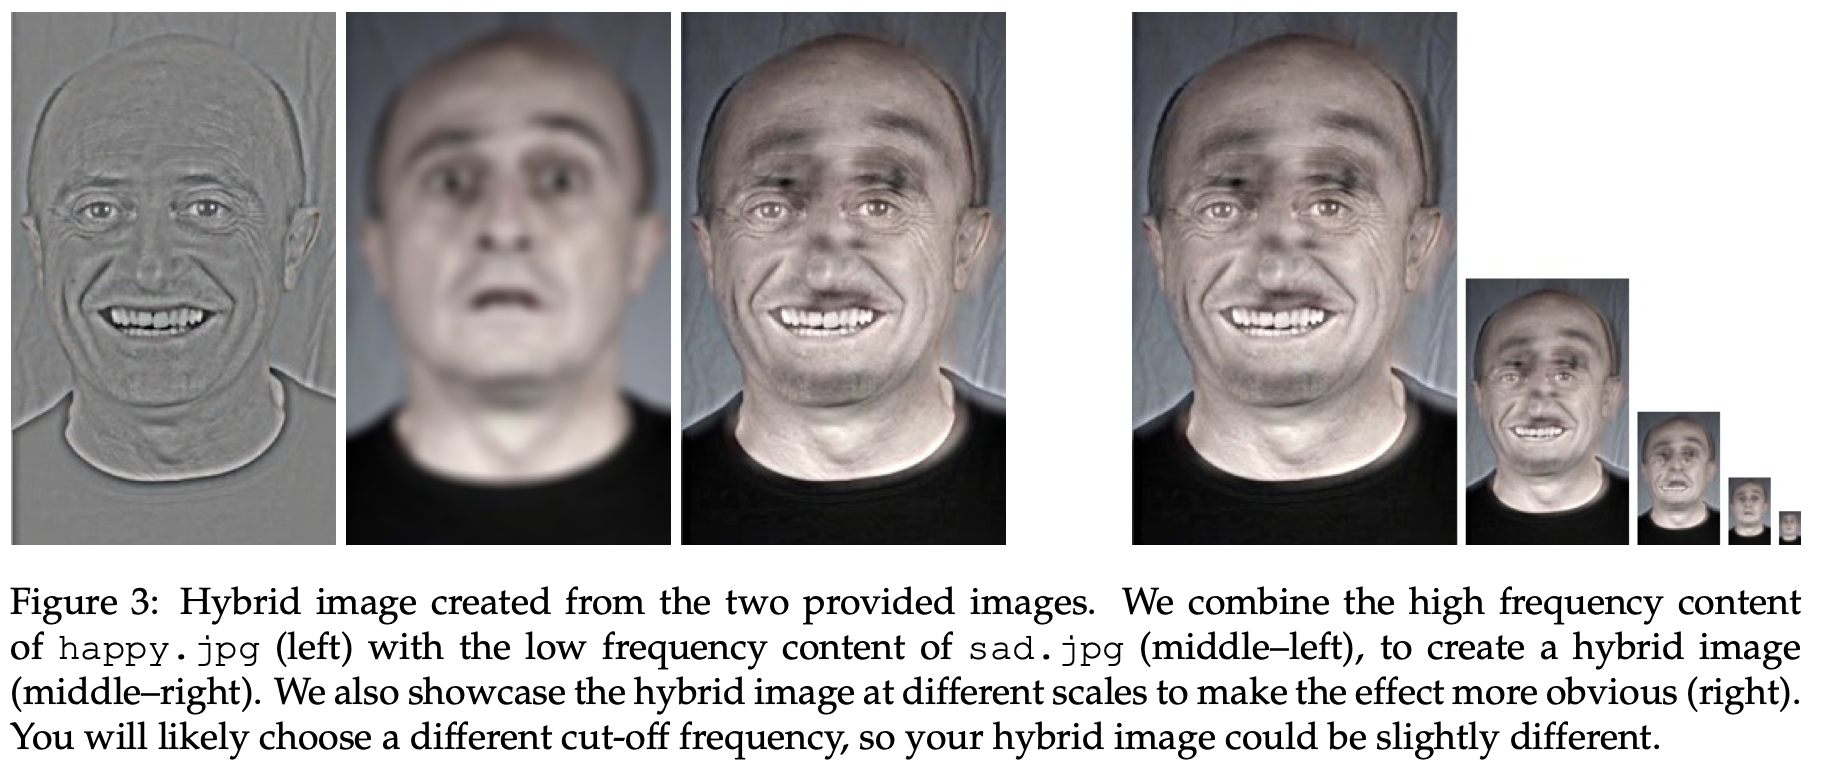

In [ ]:
# Define your functions here .- you can include comments in your code explaining the steps of your algorithm

In [ ]:
# Execute your code here

###  <span style="color:orange">  </span>
<span style="color:orange"> **Report.** _Report your results here._ </span>

## 5 Bonus: Create your own Instagram Filter! [2 Points]
You may use now your newly acquired tools in image filtering and color manipulation to create your own Instagram filter! A possible approach can be to select a specific artist or photographer you like to emulate their style, or pick a known filter you want to reproduce. You can then employ specific color mappings or filtering methods from this and previous assignments to develop your own artistic rendition. You may also try your hand at color harmonization, as seen in Lecture #8. We only impose two rules:
1. Your filter should be plug-and-play, that is, we have to be able to use it on any image, regardless of colors, image size, etc.
2. It should be implemented as a single compact MATLAB/Python function so that we can test it out ourselves.

Otherwise, we give you full freedom to use any tool you want! Apply it to several of your own images, and showcase your solution with step-by-step partial result images illustrating the process from base image to your final result. Remember to include your source of inspiration as well in the report. Note: Copy pasting the grayscale effect developed in Exercise 2 will not render extra points. You can see an example filter developed by us in Figure 4.

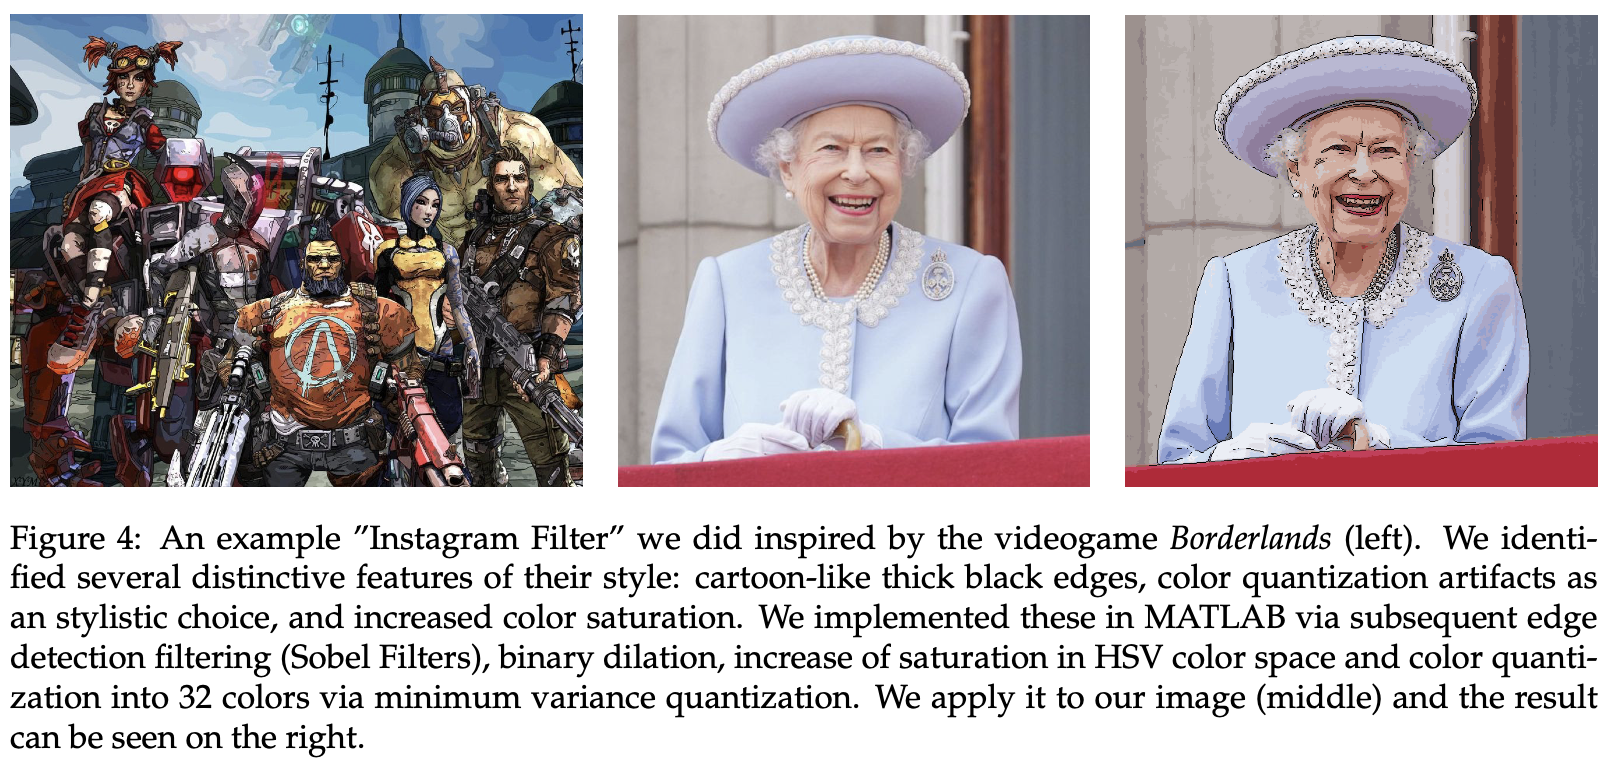

In [ ]:
# Define your functions here .- you can include comments in your code explaining the steps of your algorithm

In [ ]:
# Execute your code here

###  <span style="color:orange">  </span>
<span style="color:orange"> **Report.** _Report your results here._ </span>